In [2]:
import pandas as pd
import numpy as  np
import seaborn as sns
import scipy as sc
import statsmodels.formula.api as sfm

In [10]:
! ls ../data/*.nuc

../data/20231204_Csec_hs_5fold.nuc
../data/20231204_Csec_hs_5fold_18kss.nuc
../data/20231204_Csec_hs_5fold_background.nuc
../data/20231204_Csec_hs_5fold_background_18kss.nuc


In [13]:
bg_nuc = pd.read_csv('../data/20231204_Csec_hs_5fold_background.nuc', sep="\t")
peak_nuc = pd.read_csv('../data/20231204_Csec_hs_5fold.nuc', sep="\t")

In [16]:
peak_nuc["frac_GC"] = (peak_nuc["11_num_C"]+peak_nuc["12_num_G"])/peak_nuc["16_seq_len"]
bg_nuc["frac_GC"] = (bg_nuc["7_num_C"]+bg_nuc["8_num_G"])/bg_nuc["12_seq_len"]

,#1_usercol,2_usercol,3_usercol,4_usercol,5_usercol,6_usercol,7_usercol,8_pct_at,9_pct_gc,10_num_A,11_num_C,12_num_G,13_num_T,14_num_N,15_num_oth,16_seq_len
0,NEVH01020951.1,15000,17000,True,9.032687,52.2245,5.781724,0.5070,0.3330,463,305,361,551,320,0,2000
1,NEVH01020951.1,45000,47000,True,5.026891,29.8307,5.934225,0.5905,0.4095,601,392,427,580,0,0,2000
2,NEVH01020951.1,46000,48000,True,6.787247,39.9329,5.883520,0.5925,0.4075,591,377,438,594,0,0,2000
3,NEVH01020951.1,47000,49000,True,6.124361,35.7602,5.839009,0.5730,0.4270,589,409,445,557,0,0,2000
4,NEVH01020951.1,155000,157000,True,9.060526,92.3541,10.193017,0.5460,0.4540,513,449,459,579,0,0,2000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40587,NEVH01011202.1,2112000,2114000,True,5.607857,23.6945,4.225233,0.5920,0.4080,608,415,401,576,0,0,2000
40588,NEVH01011202.1,2174000,2176000,True,6.143364,29.1774,4.749417,0.5825,0.4175,597,424,411,568,0,0,2000
40589,NEVH01011202.1,2176000,2178000,True,6.471630,28.9723,4.476816,0.5875,0.4120,616,330,494,559,1,0,2000
40590,NEVH01011202.1,2183000,2185000,True,5.990806,28.7680,4.802025,0.5955,0.4045,544,442,367,647,0,0,2000


/tmp/ipykernel_3594687/1552812762.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(bg_nuc["frac_GC"])
/tmp/ipykernel_3594687/1552812762.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(peak_nuc["frac_GC"])


<Axes: xlabel='frac_GC', ylabel='Density'>

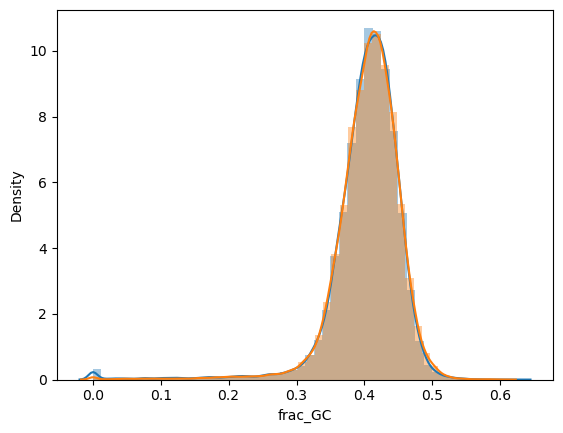

In [17]:
sns.distplot(bg_nuc["frac_GC"])
sns.distplot(peak_nuc["frac_GC"])

In [18]:
sc.stats.ttest_ind(bg_nuc["frac_GC"], peak_nuc["frac_GC"])

TtestResult(statistic=-6.118655535176133, pvalue=9.479782637211677e-10, df=81182.0)

In [19]:
bg_nuc["frac_GC"].mean()

0.4032566454667156

In [20]:
peak_nuc["frac_GC"].mean()

0.4054671838995301

In [21]:
bg_nuc["peak"] = [False for i in range(bg_nuc.shape[0])]
peak_nuc["peak"] = [True for i in range(peak_nuc.shape[0])]
all_nuc = pd.concat([bg_nuc, peak_nuc])

In [22]:
nuc_m = sfm.ols("frac_GC ~ peak", data=all_nuc)
nuc_fit = nuc_m.fit()
nuc_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                frac_GC   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     37.44
Date:                Thu, 22 Feb 2024   Prob (F-statistic):           9.48e-10
Time:                        11:45:49   Log-Likelihood:             1.2566e+05
No. Observations:               81184   AIC:                        -2.513e+05
Df Residuals:                   81182   BIC:                        -2.513e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        0.4033      0.000   1578.536      0.000       0.403       0.404
peak[T.True]     0.0022      0.000      6.119      0.000       0.002       0.003
==============================================================================
Omnibus:                    50833.971   Durbin-Watson:                   1.578
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           949967.222
Skew:                          -2.704   Prob(JB):                         0.00
Kurtosis:                      18.861   Cond. No.                         2.62
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [24]:
! ls ../data/*.nuc

../data/20231204_Csec_hs_5fold.nuc
../data/20231204_Csec_hs_5fold_18kss.nuc
../data/20231204_Csec_hs_5fold_background.nuc
../data/20231204_Csec_hs_5fold_background_18kss.nuc


In [25]:
bg_nuc_ss = pd.read_csv('../data/20231204_Csec_hs_5fold_background_18kss.nuc', sep="\t")
peak_nuc_ss = pd.read_csv('../data/20231204_Csec_hs_5fold_18kss.nuc', sep="\t")

In [26]:
peak_nuc_ss["frac_GC"] = (peak_nuc_ss["11_num_C"]+peak_nuc_ss["12_num_G"])/peak_nuc_ss["16_seq_len"]
bg_nuc_ss["frac_GC"] = (bg_nuc_ss["7_num_C"]+bg_nuc_ss["8_num_G"])/bg_nuc_ss["12_seq_len"]

/tmp/ipykernel_3594687/4135932631.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(bg_nuc_ss["frac_GC"])
/tmp/ipykernel_3594687/4135932631.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(peak_nuc_ss["frac_GC"])


<Axes: xlabel='frac_GC', ylabel='Density'>

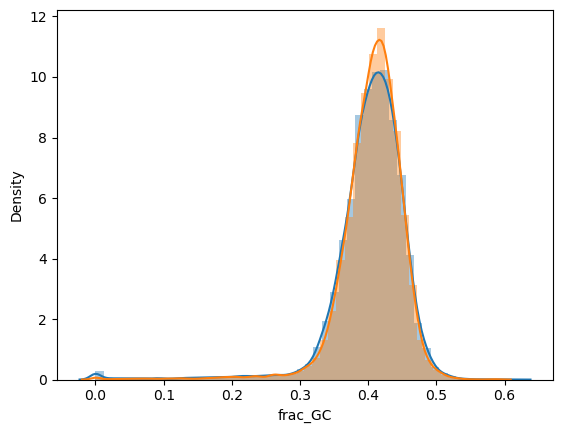

In [27]:
sns.distplot(bg_nuc_ss["frac_GC"])
sns.distplot(peak_nuc_ss["frac_GC"])

In [28]:
sc.stats.ttest_ind(bg_nuc_ss["frac_GC"], peak_nuc_ss["frac_GC"])

TtestResult(statistic=-5.402537500211058, pvalue=6.611252589195223e-08, df=36728.0)

In [29]:
bg_nuc_ss["frac_GC"].mean()

0.4026350631365925

In [30]:
peak_nuc_ss["frac_GC"].mean()

0.40554133921522234

In [31]:
bg_nuc_ss["peak"] = [False for i in range(bg_nuc_ss.shape[0])]
peak_nuc_ss["peak"] = [True for i in range(peak_nuc_ss.shape[0])]
all_nuc_ss = pd.concat([bg_nuc_ss, peak_nuc_ss])

In [32]:
nuc_m_ss = sfm.ols("frac_GC ~ peak", data=all_nuc_ss)
nuc_ss_fit = nuc_m_ss.fit()
nuc_ss_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                frac_GC   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     29.19
Date:                Thu, 22 Feb 2024   Prob (F-statistic):           6.61e-08
Time:                        11:46:56   Log-Likelihood:                 56796.
No. Observations:               36730   AIC:                        -1.136e+05
Df Residuals:                   36728   BIC:                        -1.136e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        0.4026      0.000   1057.772      0.000       0.402       0.403
peak[T.True]     0.0029      0.001      5.403      0.000       0.002       0.004
==============================================================================
Omnibus:                    24070.820   Durbin-Watson:                   1.985
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           480460.837
Skew:                          -2.860   Prob(JB):                         0.00
Kurtosis:                      19.770   Cond. No.                         2.62
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""